# Кластеризация данных сотрудников

Это набор данных предоставляет 10000 записей о сотрудниках.Данный набор предназначен для анализа кадровых тенденций, эффективности сотрудников, производительности и внутренних взаимодействиях в компании.


# Описание набора данных

База данных сотрудников содержит персональную информацию, контактные данные и сведения о должностях 10 000 работников.
Расшифровка каждого атрибута:
- Index - персональный индекс сотрудника
- First name - Имя сотрудника
- Last name - Фамилия сотрудника
- Sex - Пол сотрудника
- Email - Почта сотрудника
- Phone - Телефон сотрудника
- Date of birth - День рождения сотрудника
- Job Title - Должность

# Загрузка данных

## Подключение необходимых библиотек и функций

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%pip install openpyxl
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

## Обзор датасета

In [2]:
df = pd.read_csv("Employee 1000x.csv")

In [3]:
df

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor
...,...,...,...,...,...,...,...,...
9995,9996,Tina,Sherman,Male,bartlettcolleen@example.org,(455)476-4044x5755,28-07-74,"Scientist, physiological"
9996,9997,Earl,Jennings,Female,andreabenton@example.com,009.056.6505,20-08-32,Warehouse manager
9997,9998,Ellen,Dominguez,Female,michaelayoder@example.net,409-428-4297x469,06-06-66,Lawyer
9998,9999,Emma,Clark,Male,pstrickland@example.com,849-868-8653,09-05-07,Accounting technician


# Разведочный анализ

## Общая информация

In [4]:
df.shape

(10000, 8)

Датасет хранит в себе 10000 записей и 8 столбцов.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Index          10000 non-null  int64 
 1   First Name     10000 non-null  object
 2   Last Name      10000 non-null  object
 3   Sex            10000 non-null  object
 4   Email          10000 non-null  object
 5   Phone          10000 non-null  object
 6   Date of birth  10000 non-null  object
 7   Job Title      10000 non-null  object
dtypes: int64(1), object(7)
memory usage: 351.6+ KB


Датасет полностью заполнен, содержит 8 колонок и 10 тысяч записей. Типы данных: одна колонка числовая, а остальные — текстовые.

In [6]:
df.describe(include = "O")

,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
count,10000,10000,10000,10000,10000,10000,10000
unique,690,1000,2,9936,9992,8646,639
top,Martin,Velazquez,Female,kmendoza@example.org,-1415,22-12-06,Film/video editor
freq,28,22,5074,3,2,4,30


Этот набор не содержит пропуски. Однако в номерах телефона присутствуют аномалии.

In [7]:
print(df.duplicated().sum())

0


Дубликаты не найдены.

<ipython-input-8-907f9128862c>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='viridis')


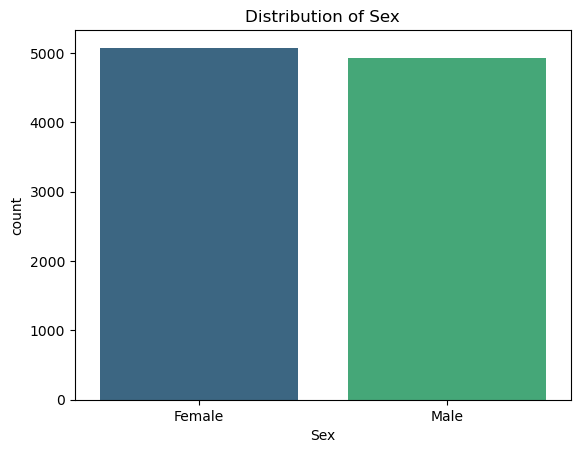

In [8]:
sns.countplot(data=df, x='Sex', palette='viridis')
plt.title('Distribution of Sex')
plt.show()

В компании женщин немного больше,чем мужчин

In [9]:
df["Job Title"].value_counts()

Job Title
Film/video editor           30
Medical secretary           28
Wellsite geologist          28
Exhibition designer         27
Probation officer           27
                            ..
Fish farm manager            7
Waste management officer     7
Chief Financial Officer      5
Theatre director             5
Holiday representative       5
Name: count, Length: 639, dtype: int64

более популярная должность это видеоредактор. Но нельзя сказать,что она распространена в компании т.к. записей всего 10000.

In [10]:
df["Date of birth"] = pd.to_datetime(df["Date of birth"],format = "%d-%m-%y",errors = "coerce")

In [11]:
df["Year"] = df["Date of birth"].dt.year
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Year
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",2021
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,1969
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,2015
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,1978
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,1989


Исправили формат дня рождения и вывели год в отдельный столбец

In [12]:
df["Age"] = 2026 - df["Year"]

In [13]:
df["Age"]

0        5
1       57
2       11
3       48
4       37
        ..
9995    52
9996    -6
9997   -40
9998    19
9999    -9
Name: Age, Length: 10000, dtype: int32

Мы четко увидели аномалии в возрасте.Попытаемся исправить их

In [14]:
from pandas.tseries.offsets import DateOffset

In [15]:
df["Original date"] = df["Date of birth"]
df.loc[df["Age"] < 0, "Date of birth"] -= DateOffset(years = 100)
df["Update Age"] = 2025 - df["Date of birth"].dt.year

In [16]:
df.loc[df["Age"]< 0]

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Year,Age,Original date,Update Age
14,15,Clayton,Erickson,Male,nterry@example.net,990-374-0521x33156,1959-02-07,Paediatric nurse,2059,-33,2059-02-07,66
19,20,Jon,Wagner,Female,meagan99@example.org,001-940-671-0693x345,1934-01-06,"Engineer, aeronautical",2034,-8,2034-01-06,91
20,21,Glen,Calderon,Male,randystephenson@example.net,4890361487,1944-09-16,"Research officer, government",2044,-18,2044-09-16,81
21,22,Marco,Sharp,Male,cmcclure@example.net,074-415-1149,1944-04-09,Retail buyer,2044,-18,2044-04-09,81
24,25,Meghan,Blanchard,Male,smejia@example.org,+1-188-201-3028x13440,1927-08-24,Occupational therapist,2027,-1,2027-08-24,98
...,...,...,...,...,...,...,...,...,...,...,...,...
9992,9993,Marvin,Davenport,Female,jade07@example.net,400-198-5125,1929-10-18,Restaurant manager,2029,-3,2029-10-18,96
9993,9994,Eddie,Clements,Female,chelsey82@example.net,855.007.8490x535,1938-06-15,Control and instrumentation engineer,2038,-12,2038-06-15,87
9996,9997,Earl,Jennings,Female,andreabenton@example.com,009.056.6505,1932-08-20,Warehouse manager,2032,-6,2032-08-20,93
9997,9998,Ellen,Dominguez,Female,michaelayoder@example.net,409-428-4297x469,1966-06-06,Lawyer,2066,-40,2066-06-06,59


In [17]:
df = df.drop(columns = ["Year", "Age", "Original date"])
df.rename(columns = {"Update Age" : "Age"}, inplace=True)

In [18]:
bins = [17,25,35,45,55,100]
labels = ["A", "B", "C", "D", "E"]
df["Age Group"] = pd.cut(df["Age"], bins = bins, labels = labels)

In [20]:
df["Job Category"] = df["Job Title"]

education = df["Job Category"].str.contains(r'\b(professor|teacher)\b', regex = True, case = False)
administration = df["Job Category"].str.contains(r'\b(officer|secretary)\b|\badmin\w*', regex = True, case = False)
healthcare = df["Job Category"].str.contains(r'\b(nurse|health|doctor)\b|psych\w*', regex = True, case = False)
manager = df["Job Category"].str.contains("manager", case = False)
tech = df["Job Category"].str.contains(r'\b(analyst|programmer|scientist)', regex = True, case = False)
engineer = df["Job Category"].str.contains("engineer", case = False)
design = df["Job Category"].str.contains(r'\b(designer|editor)\b', regex = True, case = False)
other = other = df["Job Category"].str.contains(r'\w+', regex = True)

df["Job Category"] = df["Job Category"].case_when([(education, "education"),
                                                   (administration, "administration"),
                                                   (healthcare, "healthcare"),
                                                   (manager, "manager"),
                                                   (tech, "tech"),
                                                   (engineer, "engineer"),
                                                   (design, "design"),
                                                   (other, "other")])

<ipython-input-20-44fc90004c14>:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  education = df["Job Category"].str.contains(r'\b(professor|teacher)\b', regex = True, case = False)
<ipython-input-20-44fc90004c14>:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  administration = df["Job Category"].str.contains(r'\b(officer|secretary)\b|\badmin\w*', regex = True, case = False)
<ipython-input-20-44fc90004c14>:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  healthcare = df["Job Category"].str.contains(r'\b(nurse|health|doctor)\b|psych\w*', regex = True, case = False)
<ipython-input-20-44fc90004c14>:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.ext

Вместо конкретных должностей поменяла на обобщенные категории

In [22]:
adult = df[df["Age"] >= 18]
mean_age_category = adult.groupby("Job Category")["Age"].mean()
def solve_age (row):
    if row["Age"] <= 18:
        return mean_age_category.get(row["Job Category"], np.nan)
    return row["Age"]

df["Right Age"] = df.apply(solve_age, axis = 1)

In [23]:
df["Age Group"] = pd.cut(df["Right Age"], bins = bins, labels = labels)
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age,Age Group,Job Category,Right Age
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4,E,design,58.536649
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,56,E,engineer,56.000000
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10,E,other,56.817434
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47,D,other,47.000000
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36,C,other,36.000000


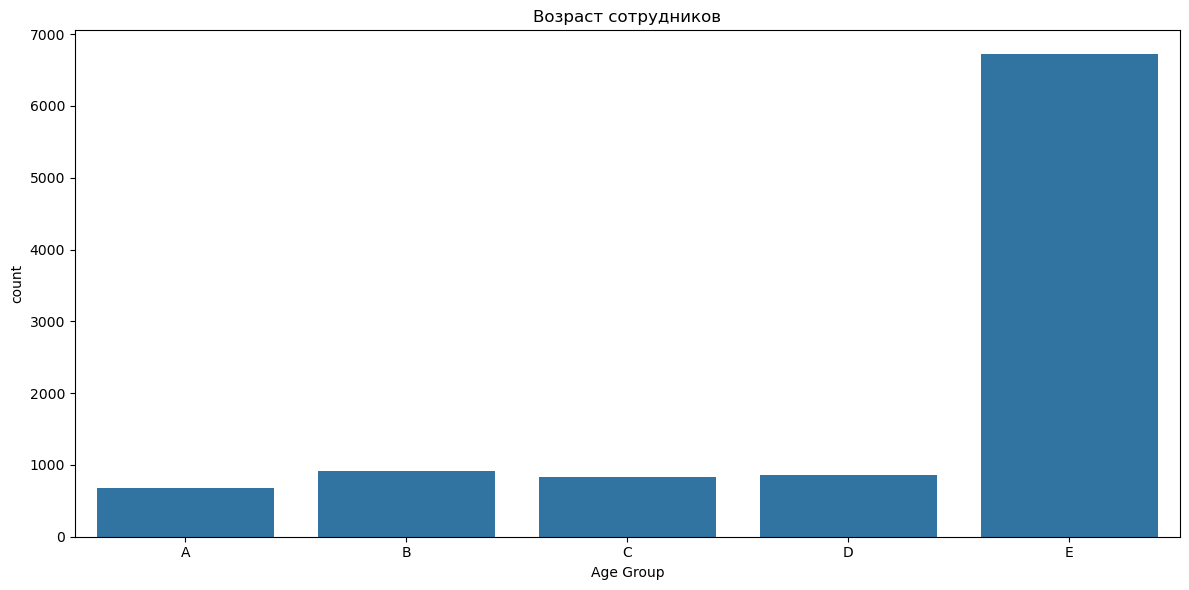

In [24]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Age Group')
plt.title('Возраст сотрудников')
plt.tight_layout()
plt.show()

- Группа А(от 18 до 25 лет)
- Группа B(от 26 до 35 лет)
- Группа C(от 36 до 45 лет)
- Группа D(от 46 до 55 лет)
- Группа E(от 56 до 100 лет)
  Как мы видим группа E превосходит численностью.

<ipython-input-43-e04738cd48f8>:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)
<ipython-input-43-e04738cd48f8>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)


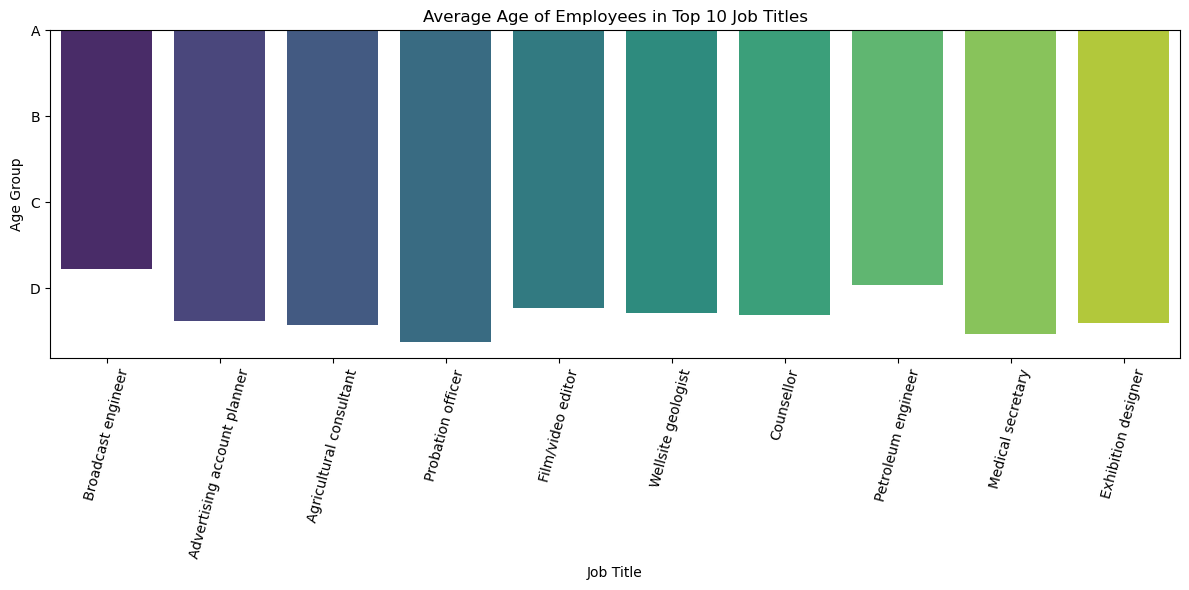

In [43]:
top_10_jobs = df["Job Title"].value_counts().head(10).index
top_10_job_data = df[df["Job Title"].isin(top_10_jobs)]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)
plt.title("Average Age of Employees in Top 10 Job Titles")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()